In [3]:
#load in necessary libraries and functions
import os
import numpy as np
import pandas as pd
import rdkit
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from rdkit.DataStructs import ConvertToNumpyArray
from sklearn.metrics import root_mean_squared_error

In [5]:
#Load your dataset; can edit based on your data of interest, but will use the lipophilicity.csv 
#set as an example for this package
df = pd.read_csv("Lipophilicity.csv")

#load in the functions from the functions.py file
from functions import generate_morgan_fps, generate_maccs_fps
# generate Morgan and MACCS fingerprints in your dataset
df = generate_morgan_fps(df)
df = generate_maccs_fps(df) 

#splitting into traing and test sets with 80/20 split
train_data, test_data = train_test_split(df, test_size=0.2) 

In [6]:
#MORGAN FINGERPRINTS
train_features_morg = [] #empty lists to hold updated features
test_features_morg = []

#converts training fingerprints into the arrays
for fp in train_data["morgan_fp"]: #for all morgan fingerprints
    arr = np.zeros(2048, dtype=int) #create an array filled with binary digits
    ConvertToNumpyArray(fp, arr) #copy the bits into the array as well
    train_features_morg.append(arr) # adds the updated array to the training features

#converts test fingerprints in a similar fashion
for fp in test_data["morgan_fp"]:
    arr = np.zeros(2048, dtype=int)
    ConvertToNumpyArray(fp, arr)
    test_features_morg.append(arr)

#saves the numpy arrays for all four variables
train_morgan_fps = np.array(train_features_morg)
train_lipo_vals = np.array(train_data["exp"])
test_morgan_fps = np.array(test_features_morg)
test_lipo_vals = np.array(test_data["exp"])

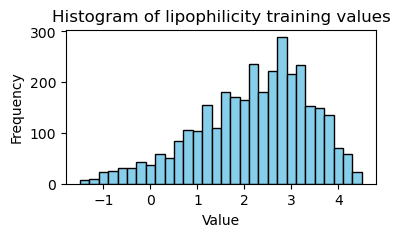

In [9]:
#MACCS KEYS
train_features_maccs = []  #empty lists to hold updated features
test_features_maccs = []

for fp in train_data["maccs_fp"]: #same method as above, for MACCS keys now
    arr = np.zeros(167, dtype=int) 
    ConvertToNumpyArray(fp, arr)
    train_features_maccs.append(arr)

for fp in test_data["maccs_fp"]:
    arr = np.zeros(167, dtype=int)
    ConvertToNumpyArray(fp, arr)
    test_features_maccs.append(arr)

#saves the numpy arrays for these two feature sets as well
train_maccs_fps = np.array(train_features_maccs)
test_maccs_fps = np.array(test_features_maccs)

plt.figure(figsize=(4,2))
plt.hist(train_lipo_vals, bins=30, color='skyblue', edgecolor='black')
plt.title("Histogram of lipophilicity training values")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

#SCALING
scaler = StandardScaler() #initializng the scaler
#apply scaler to training data and test data
train_lipo_scaled = scaler.fit_transform(train_lipo_vals.reshape(-1, 1))
test_lipo_scaled = scaler.transform(test_lipo_vals.reshape(-1, 1))
#Note: May need to change the scaling method used base on your dataset

In [10]:
#MODEL TRAINING, MORGAN FINGERPRINTS
mlp_model_morgan = MLPRegressor(random_state=1) #initialize the model (using the morgan fingerprints)
mlp_model_morgan.fit(train_morgan_fps, train_lipo_scaled) #fit the model to the training data (targets are scaled)
mlp_morg_preds_scaled = mlp_model_morgan.predict(test_morgan_fps) #predict on the test data now

#next, need to unscale the predictions and true test targets in preparation of calculating metrics
target_pred_mlp_morg = scaler.inverse_transform(mlp_morg_preds_scaled.reshape(-1, 1)).ravel()
target_true_mlp_morg = scaler.inverse_transform(test_lipo_scaled).ravel()

#Calculate and Print Metrics
mlp_morg_rmse = root_mean_squared_error(target_true_mlp_morg, target_pred_mlp_morg) #calculate rmse


/Users/maddielyon/opt/anaconda3/envs/mypackage/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [11]:
#MODEL TRAINING, MACCS KEY FINGERPRINTS
mlp_model_maccs = MLPRegressor(random_state=1) #initialize the model (using the MACCS keys)
mlp_model_maccs.fit(train_maccs_fps, train_lipo_scaled) #fit the model to the training data (targets are scaled)
mlp_maccs_preds_scaled = mlp_model_maccs.predict(test_maccs_fps) #predict on the test data now

#next, need to unscale the predictions and true test targets in preparation of calculating metrics
target_pred_mlp_maccs = scaler.inverse_transform(mlp_maccs_preds_scaled.reshape(-1, 1)).ravel()
target_true_mlp_maccs = scaler.inverse_transform(test_lipo_scaled).ravel()

#Calculate and Print Metrics
mlp_maccs_rmse = root_mean_squared_error(target_true_mlp_maccs, target_pred_mlp_maccs) #calculate rmse

/Users/maddielyon/opt/anaconda3/envs/mypackage/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/maddielyon/opt/anaconda3/envs/mypackage/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [12]:
#PRINTING/SAVING THE RESULTS
# Retrieve the current Conda environment name
conda_env = os.getenv("CONDA_DEFAULT_ENV")
print(f"Conda environment: {conda_env}") #print the name of the conda environment
print(f"RMSE for MLP model with Morgan fingerprints: {mlp_morg_rmse}") #the RMSE for morgan fp model
print(f"RMSE for MLP model with MACCS keys: {mlp_maccs_rmse}") #and RMSE for the maccs key model

Conda environment: mypackage
RMSE for MLP model with Morgan fingerprints: 0.8391970277505632
RMSE for MLP model with MACCS keys: 0.9249162353606373
